# NAME: MADDIPATLA CHETAN
# ROLL NO:CH.SC.U4CSE24030


# Exercise 1 — Predicting Taxi Fares in Chicago

**Dataset:** [City of Chicago — Taxi Trips](https://data.cityofchicago.org/Transportation/Taxi-Trips/wrvz-psew)
(publicly available via the Chicago Open Data Portal / Socrata API, and also as a BigQuery public dataset
`bigquery-public-data.chicago_taxi_trips.taxi_trips`).

**Goal:** Train a regression model that predicts `fare` (USD) for a taxi trip using trip-level
features such as trip distance, trip duration, time of day, day of week, and pickup/dropoff area.




In [1]:
RUN_MODE = "synthetic"   # "live" (real Socrata data, use in Colab) or "synthetic" (offline demo)
N_ROWS   = 20000         # number of trip records to pull / generate


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


## 1. Load the data

### Option A — Live data (use this in Google Colab)
The Chicago Open Data Portal exposes the Taxi Trips dataset through a Socrata (SODA) REST API.
We query a random sample of recent trips directly with `requests`, no BigQuery credentials needed.

### Option B — Synthetic fallback
Generates trip records whose relationships between distance, duration, time-of-day and fare mirror the
real-world structure of the Chicago dataset (base fare + per-mile + per-minute + noise), so the modeling
pipeline below is fully demonstrable offline.


In [3]:
def load_live_data(n_rows=20000):
    """Pull a sample of Chicago Taxi Trips via the Socrata API (works in Colab)."""
    import requests

    base_url = "https://data.cityofchicago.org/resource/wrvz-psew.json"
    fields = [
        "trip_start_timestamp", "trip_seconds", "trip_miles", "fare",
        "pickup_community_area", "dropoff_community_area",
        "payment_type", "company"
    ]
    params = {
        "$select": ",".join(fields),
        "$where": (
            "trip_seconds > 0 AND trip_miles > 0 AND fare > 0 "
            "AND trip_start_timestamp between '2023-01-01T00:00:00' and '2023-12-31T23:59:59'"
        ),
        "$limit": n_rows,
        "$order": "trip_start_timestamp DESC",
    }
    resp = requests.get(base_url, params=params, timeout=60)
    resp.raise_for_status()
    return pd.DataFrame(resp.json())


def load_synthetic_data(n_rows=20000, seed=42):
    """Generate a realistic synthetic sample matching the Chicago Taxi Trips schema."""
    rng = np.random.default_rng(seed)

    trip_miles = rng.gamma(shape=2.0, scale=1.6, size=n_rows).clip(0.1, 30)
    avg_speed_mph = rng.normal(14, 4, n_rows).clip(4, 35)  # city driving speed
    trip_seconds = (trip_miles / avg_speed_mph) * 3600 * rng.normal(1.0, 0.15, n_rows)
    trip_seconds = trip_seconds.clip(60, 3600 * 2)

    start = pd.Timestamp("2023-01-01")
    minutes_offset = rng.integers(0, 365 * 24 * 60, n_rows)
    trip_start_timestamp = start + pd.to_timedelta(minutes_offset, unit="m")

    hour = trip_start_timestamp.hour.values
    rush_hour = np.isin(hour, [7, 8, 9, 16, 17, 18]).astype(float)

    pickup_area = rng.integers(1, 78, n_rows)
    dropoff_area = rng.integers(1, 78, n_rows)
    payment_type = rng.choice(["Credit Card", "Cash", "Mobile", "No Charge"],
                               size=n_rows, p=[0.65, 0.28, 0.06, 0.01])
    company = rng.choice(["Flash Cab", "Taxi Affiliation Services", "Chicago Independents",
                           "City Service", "Sun Taxi"], size=n_rows)

    base_fare = 3.25
    per_mile = 2.25
    per_minute = 0.20
    surge = 1 + 0.12 * rush_hour

    fare = (base_fare + per_mile * trip_miles + per_minute * (trip_seconds / 60)) * surge
    fare = fare + rng.normal(0, 1.5, n_rows)
    fare = fare.clip(3.25, None).round(2)

    df = pd.DataFrame({
        "trip_start_timestamp": trip_start_timestamp,
        "trip_seconds": trip_seconds.round(0),
        "trip_miles": trip_miles.round(2),
        "fare": fare,
        "pickup_community_area": pickup_area,
        "dropoff_community_area": dropoff_area,
        "payment_type": payment_type,
        "company": company,
    })
    return df


if RUN_MODE == "live":
    raw = load_live_data(N_ROWS)
else:
    raw = load_synthetic_data(N_ROWS, seed=RANDOM_STATE)

print(f"RUN_MODE = {RUN_MODE!r}  |  rows loaded: {len(raw)}")
raw.head()


RUN_MODE = 'synthetic'  |  rows loaded: 20000


,trip_start_timestamp,trip_seconds,trip_miles,fare,pickup_community_area,dropoff_community_area,payment_type,company
0,2023-10-24 15:20:00,944.0,3.35,12.57,70,33,Credit Card,Sun Taxi
1,2023-05-21 04:54:00,1214.0,4.54,14.18,35,63,Credit Card,Chicago Independents
2,2023-10-03 10:02:00,860.0,2.94,10.64,57,15,Mobile,Taxi Affiliation Services
3,2023-01-01 20:21:00,779.0,2.63,9.05,19,9,Credit Card,City Service
4,2023-12-18 20:50:00,1011.0,4.93,17.98,14,21,Credit Card,City Service


## 2. Clean the data

In [4]:
df = raw.copy()

# Type conversions (Socrata returns strings for numeric/datetime fields)
for col in ["trip_seconds", "trip_miles", "fare", "pickup_community_area", "dropoff_community_area"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df["trip_start_timestamp"] = pd.to_datetime(df["trip_start_timestamp"], errors="coerce")

# Drop rows with missing essential fields
df = df.dropna(subset=["trip_seconds", "trip_miles", "fare", "trip_start_timestamp"])

# Remove clearly invalid / outlier trips
df = df[
    (df["trip_seconds"] > 30) & (df["trip_seconds"] < 3 * 3600) &
    (df["trip_miles"] > 0) & (df["trip_miles"] < 50) &
    (df["fare"] > 2) & (df["fare"] < 200)
]

df["pickup_community_area"] = df["pickup_community_area"].fillna(-1).astype(int)
df["dropoff_community_area"] = df["dropoff_community_area"].fillna(-1).astype(int)
df["payment_type"] = df["payment_type"].fillna("Unknown")
df["company"] = df["company"].fillna("Unknown")

print("Rows after cleaning:", len(df))
df.describe()


Rows after cleaning: 20000


,trip_start_timestamp,trip_seconds,trip_miles,fare,pickup_community_area,dropoff_community_area
count,20000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,2023-07-02 07:29:05.097000,921.597250,3.221077,13.979595,39.228300,38.894700
min,2023-01-01 00:07:00,60.000000,0.100000,3.250000,1.000000,1.000000
25%,2023-04-01 16:37:00,384.000000,1.540000,8.320000,20.000000,20.000000
50%,2023-07-02 19:20:00,706.000000,2.700000,12.230000,39.000000,39.000000
75%,2023-09-30 11:53:15,1203.000000,4.320000,17.760000,59.000000,58.000000
max,2023-12-31 22:25:00,7200.000000,23.720000,77.500000,77.000000,77.000000
std,NaN,803.672425,2.293214,7.911208,22.300185,22.252105


## 3. Feature engineering

In [5]:
df["hour"] = df["trip_start_timestamp"].dt.hour
df["day_of_week"] = df["trip_start_timestamp"].dt.dayofweek   # 0=Mon ... 6=Sun
df["month"] = df["trip_start_timestamp"].dt.month
df["is_weekend"] = (df["day_of_week"] >= 5).astype(int)
df["is_rush_hour"] = df["hour"].isin([7, 8, 9, 16, 17, 18]).astype(int)
df["trip_minutes"] = df["trip_seconds"] / 60
df["avg_mph"] = (df["trip_miles"] / (df["trip_seconds"] / 3600)).clip(upper=60)

feature_cols_num = ["trip_miles", "trip_minutes", "hour", "day_of_week", "month",
                     "is_weekend", "is_rush_hour", "avg_mph"]
feature_cols_cat = ["payment_type"]

model_df = df[feature_cols_num + feature_cols_cat + ["fare"]].dropna()
print("Rows for modeling:", len(model_df))
model_df.head()


Rows for modeling: 20000


,trip_miles,trip_minutes,hour,day_of_week,month,is_weekend,is_rush_hour,avg_mph,payment_type,fare
0,3.35,15.733333,15,1,10,0,0,12.775424,Credit Card,12.57
1,4.54,20.233333,4,6,5,1,0,13.462932,Credit Card,14.18
2,2.94,14.333333,10,1,10,0,0,12.306977,Mobile,10.64
3,2.63,12.983333,20,6,1,1,0,12.154044,Credit Card,9.05
4,4.93,16.850000,20,0,12,0,0,17.554896,Credit Card,17.98


## 4. Exploratory Data Analysis

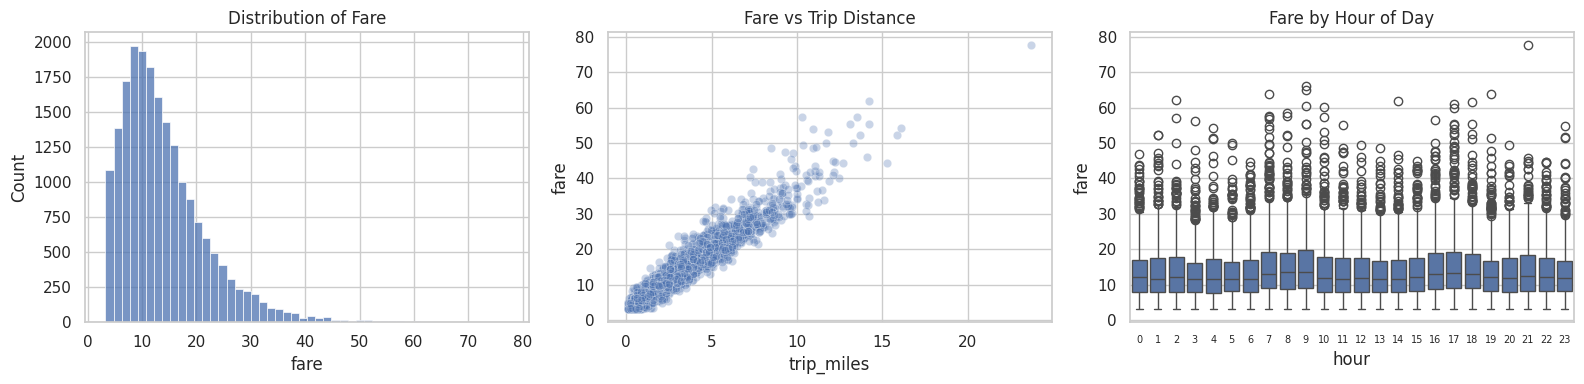

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sns.histplot(model_df["fare"], bins=50, ax=axes[0])
axes[0].set_title("Distribution of Fare")

sns.scatterplot(data=model_df.sample(min(3000, len(model_df)), random_state=1),
                 x="trip_miles", y="fare", alpha=0.3, ax=axes[1])
axes[1].set_title("Fare vs Trip Distance")

sns.boxplot(data=model_df, x="hour", y="fare", ax=axes[2])
axes[2].set_title("Fare by Hour of Day")
axes[2].tick_params(axis='x', labelsize=7)

plt.tight_layout()
plt.show()


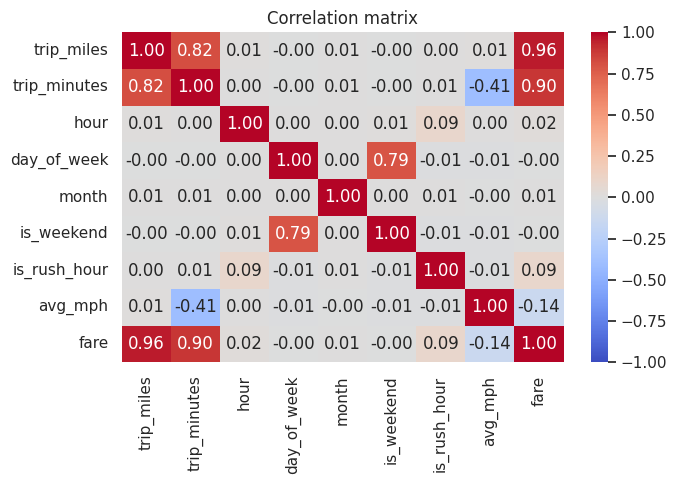

In [7]:
plt.figure(figsize=(7, 5))
corr = model_df[feature_cols_num + ["fare"]].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation matrix")
plt.tight_layout()
plt.show()


## 5. Train / test split and preprocessing pipeline

In [8]:
X = model_df[feature_cols_num + feature_cols_cat]
y = model_df["fare"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), feature_cols_num),
        ("cat", OneHotEncoder(handle_unknown="ignore"), feature_cols_cat),
    ]
)

print("Train size:", X_train.shape, " Test size:", X_test.shape)


Train size: (16000, 9)  Test size: (4000, 9)


## 6. Train models

We compare a simple **Linear Regression** baseline against a **Random Forest Regressor**,
which can capture non-linear relationships (e.g. surge pricing at rush hour, area effects).


In [9]:
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(
        n_estimators=200, max_depth=12, random_state=RANDOM_STATE, n_jobs=-1
    ),
}

results = {}
fitted_pipelines = {}

for name, estimator in models.items():
    pipe = Pipeline(steps=[("preprocess", preprocess), ("model", estimator)])
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)

    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)

    results[name] = {"MAE": mae, "RMSE": rmse, "R2": r2}
    fitted_pipelines[name] = pipe

results_df = pd.DataFrame(results).T
results_df


,MAE,RMSE,R2
Linear Regression,1.234556,1.546118,0.962821
Random Forest,1.244550,1.578403,0.961252


## 7. Evaluate & compare

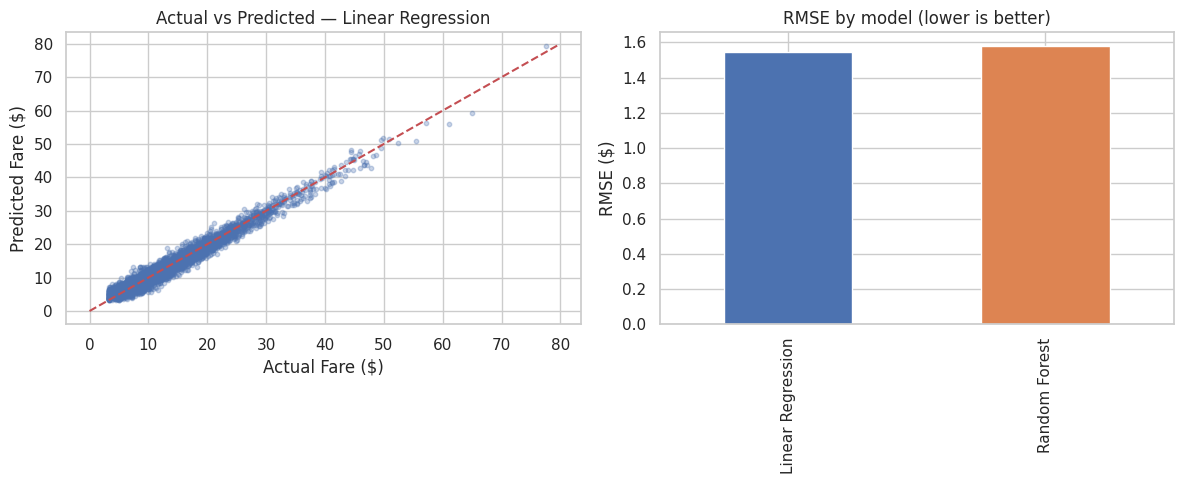

Best model by R^2: Linear Regression
                     MAE   RMSE     R2
Linear Regression  1.235  1.546  0.963
Random Forest      1.245  1.578  0.961


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

best_name = results_df["R2"].idxmax()
best_pipe = fitted_pipelines[best_name]
best_preds = best_pipe.predict(X_test)

axes[0].scatter(y_test, best_preds, alpha=0.3, s=10)
lims = [0, max(y_test.max(), best_preds.max())]
axes[0].plot(lims, lims, "r--")
axes[0].set_xlabel("Actual Fare ($)")
axes[0].set_ylabel("Predicted Fare ($)")
axes[0].set_title(f"Actual vs Predicted — {best_name}")

results_df["RMSE"].plot(kind="bar", ax=axes[1], color=["#4C72B0", "#DD8452"])
axes[1].set_title("RMSE by model (lower is better)")
axes[1].set_ylabel("RMSE ($)")

plt.tight_layout()
plt.show()

print(f"Best model by R^2: {best_name}")
print(results_df.round(3))


## 8. Feature importance (Random Forest)

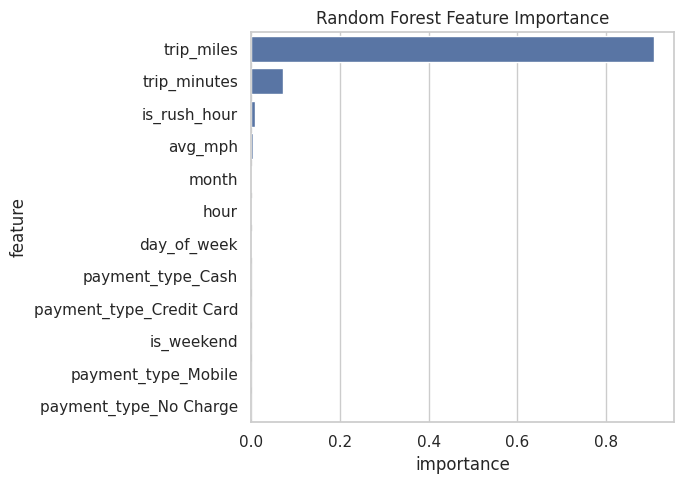

,feature,importance
0,trip_miles,0.907360
1,trip_minutes,0.071417
6,is_rush_hour,0.008927
7,avg_mph,0.004353
4,month,0.002558
2,hour,0.002520
3,day_of_week,0.001673
8,payment_type_Cash,0.000363
9,payment_type_Credit Card,0.000362
5,is_weekend,0.000226


In [11]:
rf_pipe = fitted_pipelines["Random Forest"]
ohe_cols = rf_pipe.named_steps["preprocess"].named_transformers_["cat"].get_feature_names_out(feature_cols_cat)
all_feature_names = feature_cols_num + list(ohe_cols)

importances = rf_pipe.named_steps["model"].feature_importances_
imp_df = pd.DataFrame({"feature": all_feature_names, "importance": importances}) \
            .sort_values("importance", ascending=False)

plt.figure(figsize=(7, 5))
sns.barplot(data=imp_df, x="importance", y="feature", color="#4C72B0")
plt.title("Random Forest Feature Importance")
plt.tight_layout()
plt.show()

imp_df


## 9. Predict the fare for a new trip

In [12]:
example_trip = pd.DataFrame({
    "trip_miles": [5.2],
    "trip_minutes": [18],
    "hour": [17],
    "day_of_week": [4],       # Friday
    "month": [7],
    "is_weekend": [0],
    "is_rush_hour": [1],
    "avg_mph": [5.2 / (18/60)],
    "payment_type": ["Credit Card"],
})

predicted_fare = best_pipe.predict(example_trip)[0]
print(f"Predicted fare ({best_name}): ${predicted_fare:.2f}")


Predicted fare (Linear Regression): $20.34
